<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/03__April_Logistic_Regression_3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Science Masters

## Q1. Precision and Recall in Classification Models

### Concept

Before understanding Precision and Recall, we need to understand the **Confusion Matrix**:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | TP (True Positive) | FN (False Negative) |
| **Actual Negative** | FP (False Positive) | TN (True Negative) |

### Precision
**Precision** answers: *Of all instances predicted as Positive, how many were actually Positive?*

$$\text{Precision} = \frac{TP}{TP + FP}$$

- High Precision → Low False Positive Rate
- Important when the **cost of False Positives is high** (e.g., spam detection — you don't want to mark legitimate emails as spam)

### Recall (Sensitivity / True Positive Rate)
**Recall** answers: *Of all actual Positive instances, how many did the model correctly identify?*

$$\text{Recall} = \frac{TP}{TP + FN}$$

- High Recall → Low False Negative Rate
- Important when the **cost of False Negatives is high** (e.g., cancer detection — missing a cancer case is dangerous)

### Precision-Recall Tradeoff
There is an inherent tradeoff: increasing precision often decreases recall and vice versa. This is controlled by the **classification threshold**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


         CONFUSION MATRIX BREAKDOWN
  True Positives  (TP): 36
  True Negatives  (TN): 129
  False Positives (FP): 11
  False Negatives (FN): 24
---------------------------------------------
  Precision = TP/(TP+FP) = 36/(36+11) = 0.7660
  Recall    = TP/(TP+FN) = 36/(36+24) = 0.6000


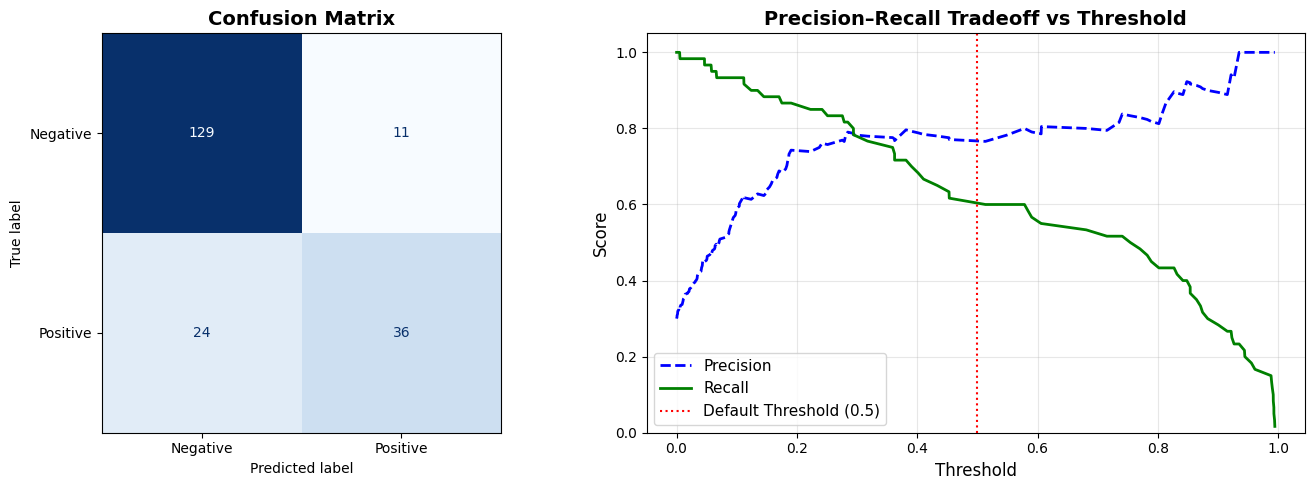

Q1 visualization saved.


In [2]:
#  Q1 Demo: Precision and Recall

# Generate a binary classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2,
                           random_state=42, weights=[0.7, 0.3])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Compute metrics
cm = confusion_matrix(y_test, y_pred)
TP = cm[1, 1]; FP = cm[0, 1]; FN = cm[1, 0]; TN = cm[0, 0]

precision = TP / (TP + FP)
recall    = TP / (TP + FN)

print("=" * 45)
print("         CONFUSION MATRIX BREAKDOWN")
print("=" * 45)
print(f"  True Positives  (TP): {TP}")
print(f"  True Negatives  (TN): {TN}")
print(f"  False Positives (FP): {FP}")
print(f"  False Negatives (FN): {FN}")
print("-" * 45)
print(f"  Precision = TP/(TP+FP) = {TP}/({TP}+{FP}) = {precision:.4f}")
print(f"  Recall    = TP/(TP+FN) = {TP}/({TP}+{FN}) = {recall:.4f}")
print("=" * 45)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix", fontsize=14, fontweight='bold')

# Precision-Recall tradeoff
y_proba = clf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
axes[1].plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
axes[1].plot(thresholds, recalls[:-1],    'g-',  label='Recall',    linewidth=2)
axes[1].axvline(x=0.5, color='red', linestyle=':', label='Default Threshold (0.5)')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision–Recall Tradeoff vs Threshold', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 1.05])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q1_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q1 visualization saved.")

---
## Q2. F1 Score — Definition, Calculation & Comparison

### What is the F1 Score?
The **F1 Score** is the **harmonic mean** of Precision and Recall. It balances both metrics into a single number, which is especially useful when you have an **imbalanced dataset**.

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

### Why Harmonic Mean?
The harmonic mean **penalizes extreme values**. If either Precision or Recall is very low, the F1 score will also be low — unlike the arithmetic mean.

| Metric | Formula | Focuses On |
|--------|---------|------------|
| Precision | TP / (TP + FP) | Correctness of positive predictions |
| Recall | TP / (TP + FN) | Coverage of actual positives |
| F1 Score | Harmonic mean of P & R | Balance between P and R |

### When to use each?
- **Precision**: When false positives are costly (e.g., spam filter)
- **Recall**: When false negatives are costly (e.g., fraud/disease detection)
- **F1**: When you need a **balance** of both, especially with imbalanced classes

### F-beta Score (Generalization)
$$F_\beta = (1 + \beta^2) \times \frac{\text{Precision} \times \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$
- β > 1 → weights Recall more
- β < 1 → weights Precision more
- β = 1 → standard F1

           F1 SCORE BREAKDOWN
  Precision : 0.7660
  Recall    : 0.6000
  F1 (manual): 0.6729
  F1 (sklearn): 0.6729

  Harmonic Mean vs Arithmetic Mean Comparison:
      P     R    F1 (HM)         AM
  -----------------------------------
    0.9   0.1     0.1800     0.5000
    0.5   0.5     0.5000     0.5000
    0.1   0.9     0.1800     0.5000


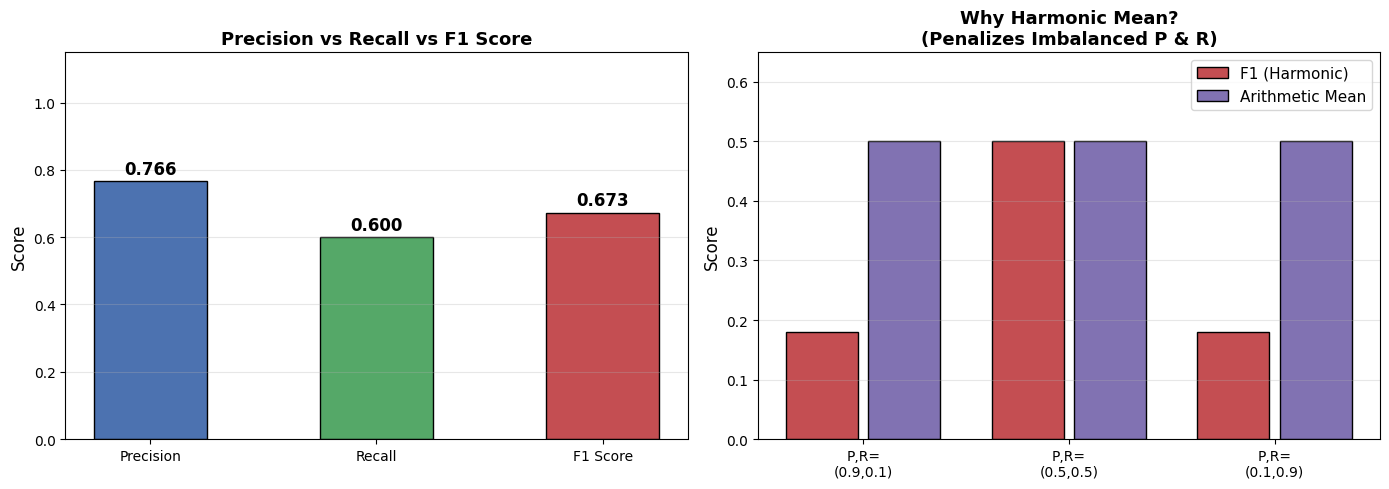

Q2 visualization saved.


In [3]:
# Q2 Demo: F1 Score

f1 = f1_score(y_test, y_pred)
f1_manual = 2 * precision * recall / (precision + recall)

print("=" * 45)
print("           F1 SCORE BREAKDOWN")
print("=" * 45)
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 (manual): {f1_manual:.4f}")
print(f"  F1 (sklearn): {f1:.4f}")
print("=" * 45)

# Demonstrate the harmonic mean penalty
p_vals = [0.9, 0.5, 0.1]
r_vals = [0.1, 0.5, 0.9]
print("\n  Harmonic Mean vs Arithmetic Mean Comparison:")
print(f"  {'P':>5} {'R':>5} {'F1 (HM)':>10} {'AM':>10}")
print("  " + "-"*35)
for p, r in zip(p_vals, r_vals):
    hm = 2*p*r/(p+r)
    am = (p+r)/2
    print(f"  {p:>5.1f} {r:>5.1f} {hm:>10.4f} {am:>10.4f}")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Precision', 'Recall', 'F1 Score']
values  = [precision, recall, f1]
colors  = ['#4C72B0', '#55A868', '#C44E52']
bars = axes[0].bar(metrics, values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Precision vs Recall vs F1 Score', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Harmonic vs Arithmetic mean
pairs = ['(0.9,0.1)', '(0.5,0.5)', '(0.1,0.9)']
hm_vals = [2*p*r/(p+r) for p,r in zip(p_vals,r_vals)]
am_vals = [(p+r)/2     for p,r in zip(p_vals,r_vals)]
x = np.arange(len(pairs))
axes[1].bar(x - 0.2, hm_vals, 0.35, label='F1 (Harmonic)', color='#C44E52', edgecolor='black')
axes[1].bar(x + 0.2, am_vals, 0.35, label='Arithmetic Mean', color='#8172B2', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'P,R=\n{p}' for p in pairs], fontsize=10)
axes[1].set_ylim(0, 0.65)
axes[1].set_title('Why Harmonic Mean?\n(Penalizes Imbalanced P & R)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q2_f1_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q2 visualization saved.")

---
## Q3. ROC Curve and AUC

### ROC (Receiver Operating Characteristic) Curve
The **ROC curve** plots the **True Positive Rate (Recall)** vs **False Positive Rate** at various classification thresholds.

$$\text{True Positive Rate (TPR)} = \frac{TP}{TP + FN} \quad \text{(= Recall)}$$

$$\text{False Positive Rate (FPR)} = \frac{FP}{FP + TN}$$

### AUC (Area Under the ROC Curve)
**AUC** quantifies the overall performance across all thresholds:

| AUC Value | Interpretation |
|-----------|----------------|
| 1.0 | Perfect classifier |
| 0.9 – 1.0 | Excellent |
| 0.8 – 0.9 | Good |
| 0.7 – 0.8 | Fair |
| 0.6 – 0.7 | Poor |
| 0.5 | Random classifier (no skill) |
| < 0.5 | Worse than random |

### How AUC is Used
- **Model comparison**: Higher AUC = better overall performance
- **Threshold-independent**: Unlike F1, it evaluates across ALL thresholds
- **Imbalanced datasets**: More reliable than accuracy

        ROC-AUC SCORES BY MODEL
  Logistic Regression   : AUC = 0.9119
  Random Forest         : AUC = 0.9117
  SVM                   : AUC = 0.9075


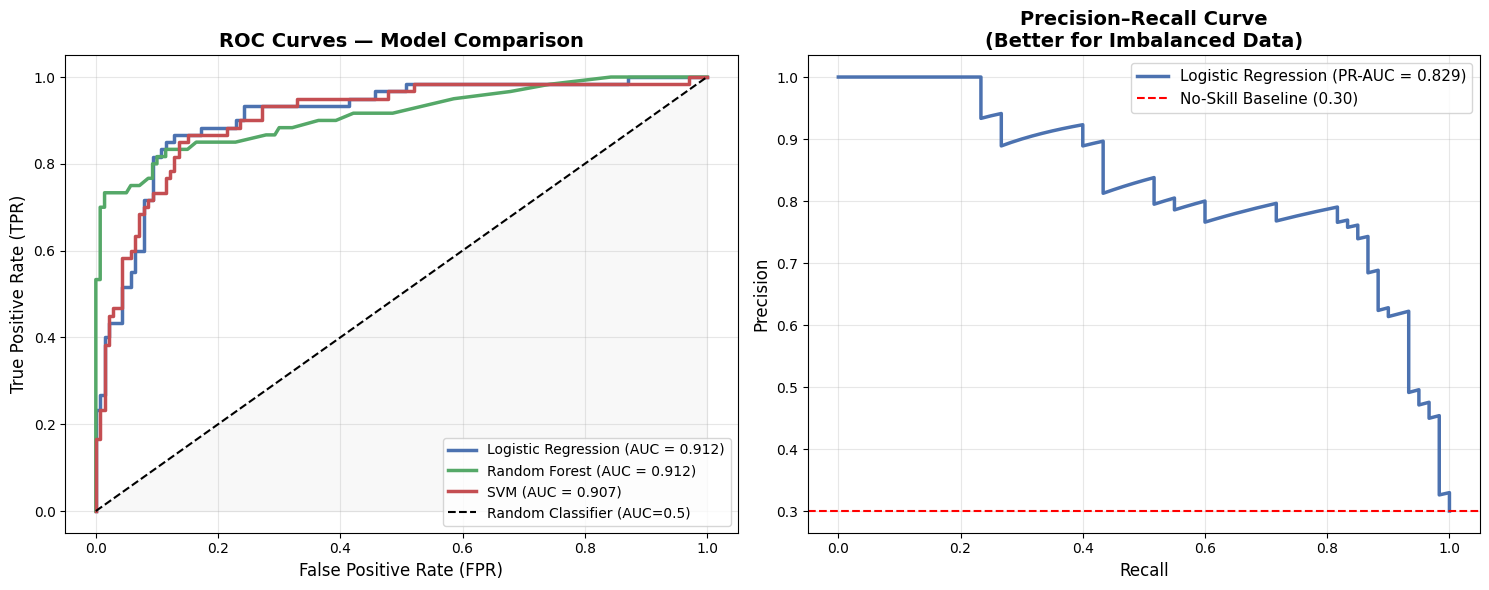

Q3 visualization saved.


In [5]:
#  Q3 Demo: ROC Curve and AUC

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Train multiple models for comparison
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42)
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#4C72B0', '#55A868', '#C44E52']

print("=" * 45)
print("        ROC-AUC SCORES BY MODEL")
print("=" * 45)

for (name, model), color in zip(models.items(), colors):
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    print(f"  {name:<22}: AUC = {roc_auc:.4f}")
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC = {roc_auc:.3f})')

print("=" * 45)

axes[0].plot([0,1],[0,1], 'k--', linewidth=1.5, label='Random Classifier (AUC=0.5)')
axes[0].fill_between([0,1],[0,1], alpha=0.05, color='gray')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0].set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall curve (complementary to ROC)
clf.fit(X_train, y_train)
y_proba_lr = clf.predict_proba(X_test)[:, 1]
precs, recs, threshs = precision_recall_curve(y_test, y_proba_lr)
pr_auc = auc(recs, precs)
axes[1].plot(recs, precs, color='#4C72B0', linewidth=2.5,
             label=f'Logistic Regression (PR-AUC = {pr_auc:.3f})')
baseline = y_test.sum() / len(y_test)
axes[1].axhline(y=baseline, color='red', linestyle='--', linewidth=1.5,
                label=f'No-Skill Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision–Recall Curve\n(Better for Imbalanced Data)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q3_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q3 visualization saved.")

---
## Q4. Choosing the Best Metric for a Classification Model

Selecting the right metric depends on **business context, class distribution, and the cost of errors**.

### Decision Framework

| Scenario | Recommended Metric | Reason |
|---|---|---|
| Balanced classes, equal error costs | **Accuracy** | Simple and interpretable |
| Imbalanced classes | **F1 / AUC-ROC** | Accuracy is misleading |
| False Positives are costly | **Precision** | Spam detection, legal verdicts |
| False Negatives are costly | **Recall** | Disease/fraud detection |
| Need threshold-independent measure | **AUC-ROC** | Compares models holistically |
| Severe class imbalance | **PR-AUC** | More sensitive than ROC-AUC |
| Multiclass classification | **Macro/Weighted F1** | Accounts for all classes |

### Key Questions to Ask:
1. **Are classes balanced?** → If no, avoid accuracy
2. **What is the cost of FP vs FN?** → Determines Precision vs Recall priority
3. **Do you need a single threshold decision?** → F1; threshold-independent? → AUC
4. **Is interpretability important?** → Accuracy or Precision

---
## What is Multiclass Classification?

**Binary Classification**: Output is one of **2 classes** (e.g., spam/not spam, 0/1)

**Multiclass Classification**: Output is one of **3+ classes** (e.g., dog/cat/bird, digit 0–9)

| Feature | Binary | Multiclass |
|---|---|---|
| Number of classes | 2 | ≥ 3 |
| Output probabilities | Single sigmoid | Softmax over all classes |
| Decision boundary | 1 boundary | Multiple boundaries |
| Metrics | Precision, Recall, F1 | Macro/Micro/Weighted averages |
| Logistic Regression | Direct | OvR or Multinomial |

### Strategies for Multiclass:
- **One-vs-Rest (OvR)**: Train K binary classifiers (each class vs all others)
- **One-vs-One (OvO)**: Train K(K−1)/2 classifiers (each pair of classes)
- **Multinomial (Softmax)**: Single model with softmax output

  IMBALANCED DATA — Accuracy vs F1 Trap
  Dataset: 950 class-0, 50 class-1 (95:5 split)
  Strategy: Always predict class 0
  Accuracy : 0.9500  ← Looks great!
  F1 Score : 0.0000    ← Reveals the truth


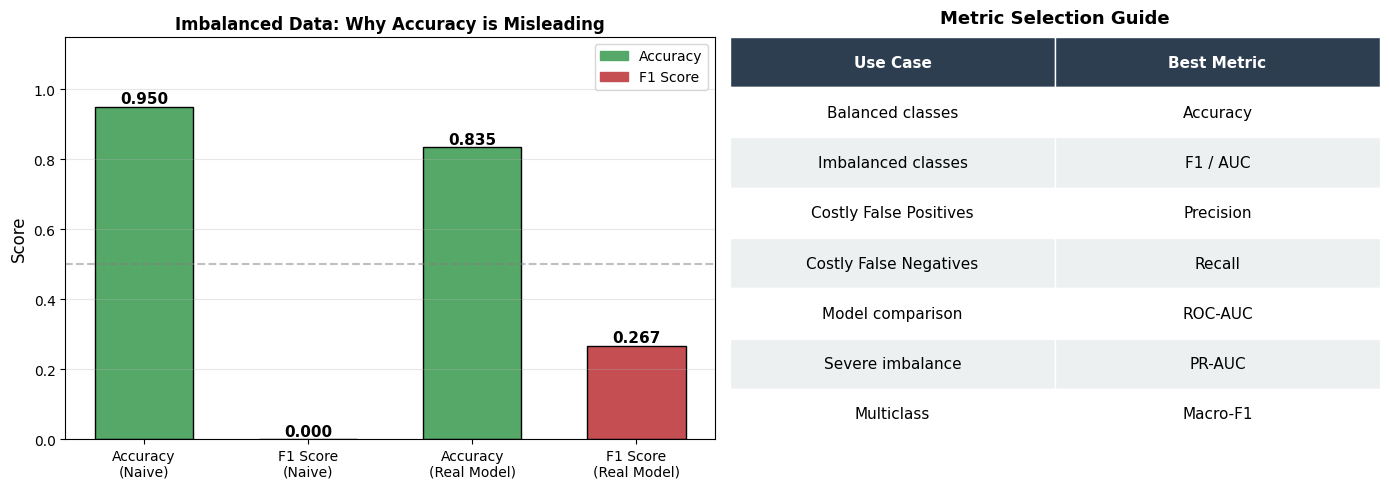

Q4 visualization saved.


In [6]:
# Q4 Demo: Metric Selection & Multiclass Overview

# Show how accuracy can be misleading with imbalanced data
y_imbalanced      = np.array([0]*950 + [1]*50)
y_pred_naive      = np.zeros(1000, dtype=int)  # always predict majority class

acc_naive = (y_pred_naive == y_imbalanced).mean()
f1_naive  = f1_score(y_imbalanced, y_pred_naive, zero_division=0)

print("=" * 50)
print("  IMBALANCED DATA — Accuracy vs F1 Trap")
print("=" * 50)
print(f"  Dataset: 950 class-0, 50 class-1 (95:5 split)")
print(f"  Strategy: Always predict class 0")
print(f"  Accuracy : {acc_naive:.4f}  ← Looks great!")
print(f"  F1 Score : {f1_naive:.4f}    ← Reveals the truth")
print("=" * 50)

# Decision tree visualization for metric selection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metric comparison on imbalanced data
categories = ['Accuracy\n(Naive)', 'F1 Score\n(Naive)', 'Accuracy\n(Real Model)', 'F1 Score\n(Real Model)']
real_model  = LogisticRegression(class_weight='balanced', random_state=42)

X_imb, y_imb = make_classification(n_samples=1000, weights=[0.95, 0.05], random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42)
real_model.fit(Xtr, ytr)
y_pred_real = real_model.predict(Xte)

vals   = [acc_naive, f1_naive,
          (y_pred_real == yte).mean(), f1_score(yte, y_pred_real)]
colors = ['#55A868','#C44E52','#55A868','#C44E52']
bars   = axes[0].bar(categories, vals, color=colors, edgecolor='black', width=0.6)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                 f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Imbalanced Data: Why Accuracy is Misleading', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)
green_patch = mpatches.Patch(color='#55A868', label='Accuracy')
red_patch   = mpatches.Patch(color='#C44E52', label='F1 Score')
axes[0].legend(handles=[green_patch, red_patch], fontsize=10)

# Metric guide summary
axes[1].axis('off')
table_data = [
    ['Use Case', 'Best Metric'],
    ['Balanced classes', 'Accuracy'],
    ['Imbalanced classes', 'F1 / AUC'],
    ['Costly False Positives', 'Precision'],
    ['Costly False Negatives', 'Recall'],
    ['Model comparison', 'ROC-AUC'],
    ['Severe imbalance', 'PR-AUC'],
    ['Multiclass', 'Macro-F1'],
]
table = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                      cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ECF0F1')
    cell.set_edgecolor('white')
axes[1].set_title('Metric Selection Guide', fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('q4_metric_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q4 visualization saved.")

---
## Q5. Logistic Regression for Multiclass Classification

Logistic Regression is inherently a **binary** classifier, but it can be extended to multiclass using two strategies:

### Strategy 1: One-vs-Rest (OvR / OvA)
- Train **K separate binary classifiers** (one per class)
- Each classifier learns: *Is this class K or not?*
- Predict the class with the **highest probability**
- sklearn: `multi_class='ovr'`

### Strategy 2: Multinomial (Softmax Regression)
- Train a **single model** over all K classes simultaneously
- Uses the **Softmax function** to produce probability distribution:

$$P(y=k | x) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}$$

- All probabilities sum to 1
- sklearn: `multi_class='multinomial'`, `solver='lbfgs'`

### Comparison

| | One-vs-Rest | Multinomial |
|---|---|---|
| Models trained | K | 1 |
| Output | Max of K probabilities | Softmax distribution |
| Probabilities sum to 1? | No (approximately) | Yes |
| Best for | Any solver | lbfgs, newton-cg, sag |
| Computational cost | Higher | Lower |

    LOGISTIC REGRESSION — MULTICLASS COMPARISON
  Metric                           OvR  Multinomial
  --------------------------------------------------
  Accuracy                      0.9556       1.0000
  F1 (macro)                    0.9484       1.0000
  Precision (macro)             0.9556       1.0000
  Recall (macro)                0.9487       1.0000

  Classification Report (Multinomial):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



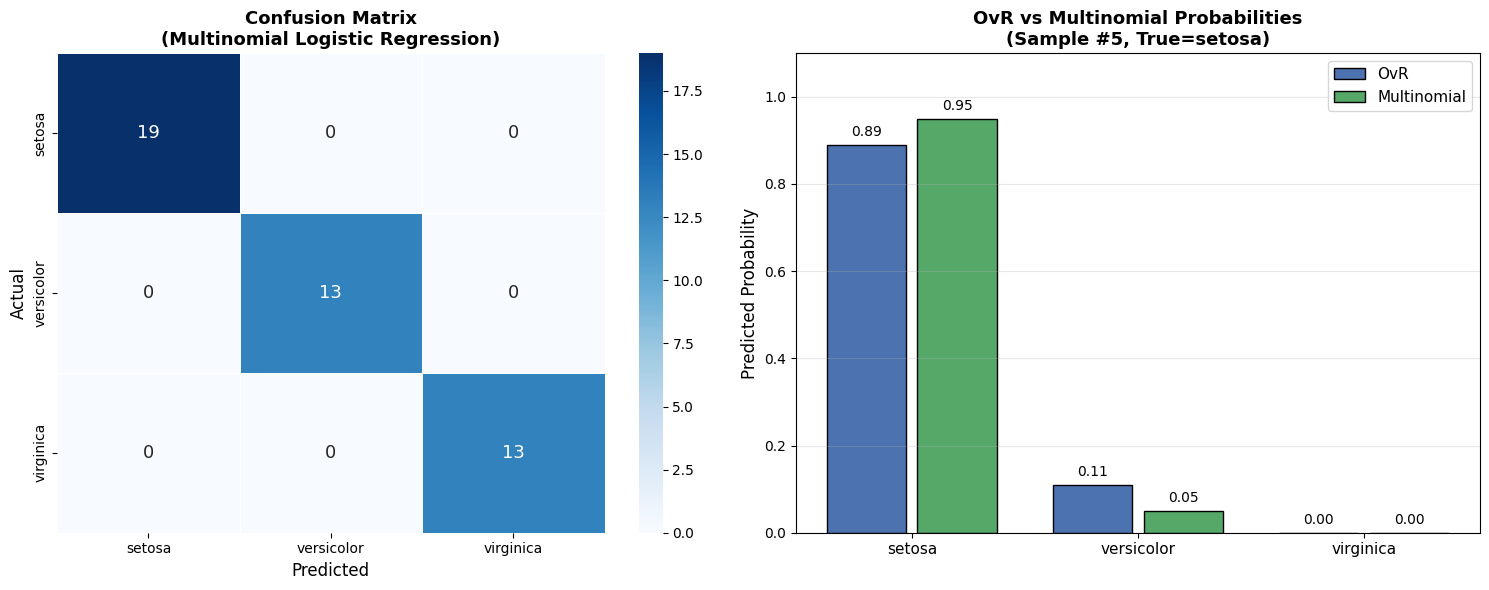

Q5 visualization saved.


In [7]:
#  Q5 Demo: Logistic Regression for Multiclass

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
class_names = iris.target_names

X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

# OvR model
ovr_model = LogisticRegression(multi_class='ovr',        solver='lbfgs', max_iter=200)
# Multinomial model
mn_model  = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)

ovr_model.fit(X_tr, y_tr)
mn_model.fit(X_tr, y_tr)

y_pred_ovr = ovr_model.predict(X_te)
y_pred_mn  = mn_model.predict(X_te)

print("=" * 55)
print("    LOGISTIC REGRESSION — MULTICLASS COMPARISON")
print("=" * 55)
print(f"  {'Metric':<25} {'OvR':>10} {'Multinomial':>12}")
print("  " + "-" * 50)
for metric_name, fn in [("Accuracy", lambda y,p: (y==p).mean()),
                         ("F1 (macro)", lambda y,p: f1_score(y,p,average='macro')),
                         ("Precision (macro)", lambda y,p: precision_score(y,p,average='macro')),
                         ("Recall (macro)", lambda y,p: recall_score(y,p,average='macro'))]:
    v1 = fn(y_te, y_pred_ovr)
    v2 = fn(y_te, y_pred_mn)
    print(f"  {metric_name:<25} {v1:>10.4f} {v2:>12.4f}")
print("=" * 55)

print("\n  Classification Report (Multinomial):")
print(classification_report(y_te, y_pred_mn, target_names=class_names))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion matrix for multinomial
cm_mn = confusion_matrix(y_te, y_pred_mn)
sns.heatmap(cm_mn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0],
            linewidths=0.5, linecolor='white', annot_kws={'size': 13})
axes[0].set_title('Confusion Matrix\n(Multinomial Logistic Regression)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Probability output for a sample
sample_idx = 5
proba_ovr = ovr_model.predict_proba(X_te)[sample_idx]
proba_mn  = mn_model.predict_proba(X_te)[sample_idx]
x = np.arange(len(class_names))
axes[1].bar(x - 0.2, proba_ovr, 0.35, label='OvR',         color='#4C72B0', edgecolor='black')
axes[1].bar(x + 0.2, proba_mn,  0.35, label='Multinomial', color='#55A868', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, fontsize=11)
axes[1].set_ylabel('Predicted Probability', fontsize=12)
axes[1].set_title(f'OvR vs Multinomial Probabilities\n(Sample #{sample_idx}, True={class_names[y_te[sample_idx]]})',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)
for i, (p1,p2) in enumerate(zip(proba_ovr, proba_mn)):
    axes[1].text(i-0.2, p1+0.02, f'{p1:.2f}', ha='center', fontsize=10)
    axes[1].text(i+0.2, p2+0.02, f'{p2:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('q5_multiclass_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q5 visualization saved.")

---
## Q6. End-to-End Project: Multiclass Classification Pipeline

### Steps in an End-to-End Multiclass Classification Project

```
1. Problem Definition
   └─ Define objectives, success criteria, and constraints

2. Data Collection
   └─ Gather data from databases, APIs, files, web scraping

3. Exploratory Data Analysis (EDA)
   └─ Class distribution, feature statistics, correlations, visualizations

4. Data Preprocessing
   └─ Handle missing values, outliers, encoding, normalization

5. Feature Engineering
   └─ Create new features, select important features, dimensionality reduction

6. Model Selection & Training
   └─ Choose algorithms, train-test split, cross-validation

7. Model Evaluation
   └─ Metrics: Accuracy, Macro-F1, Confusion Matrix, ROC-AUC

8. Hyperparameter Tuning
   └─ GridSearchCV, RandomizedSearchCV, Bayesian Optimization

9. Model Deployment
   └─ Save model (pickle/joblib), build API (Flask/FastAPI), containerize (Docker)

10. Monitoring & Maintenance
    └─ Monitor drift, retrain periodically, A/B testing
```

In [8]:
# ── Q6 Demo: Complete End-to-End Pipeline on Iris Dataset ──

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
import joblib

print("STEP 1: Problem Definition")
print("-" * 40)
print("  Task: Classify Iris flowers into 3 species")
print("  Features: sepal length, sepal width, petal length, petal width")
print("  Target: setosa, versicolor, virginica")

print("\nSTEP 2: Data Collection & EDA")
print("-" * 40)
iris = load_iris()
X, y = iris.data, iris.target
print(f"  Dataset shape: {X.shape}")
print(f"  Class distribution: {dict(zip(iris.target_names, np.bincount(y)))}")
print(f"  Missing values: {np.isnan(X).sum()}")
print(f"  Feature ranges:")
for i, fname in enumerate(iris.feature_names):
    print(f"    {fname:<25}: [{X[:,i].min():.1f}, {X[:,i].max():.1f}]")

print("\nSTEP 3-4: Preprocessing & Train-Test Split")
print("-" * 40)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"  Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

print("\nSTEP 5-6: Pipeline Creation & Model Training")
print("-" * 40)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200))
])

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')
print(f"  5-Fold CV F1-Macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\nSTEP 7: Hyperparameter Tuning")
print("-" * 40)
param_grid = {'classifier__C': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"  Best C: {grid_search.best_params_['classifier__C']}")
print(f"  Best CV F1: {grid_search.best_score_:.4f}")

print("\nSTEP 8: Final Evaluation on Test Set")
print("-" * 40)
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred_final = best_model.predict(X_test)
print(classification_report(y_test, y_pred_final, target_names=iris.target_names))

print("STEP 9: Model Serialization")
print("-" * 40)
joblib.dump(best_model, 'iris_classifier.pkl')
loaded_model = joblib.load('iris_classifier.pkl')
sample = X_test[[0]]
prediction = iris.target_names[loaded_model.predict(sample)[0]]
print(f"  Model saved and reloaded successfully!")
print(f"  Sample prediction: {prediction} (actual: {iris.target_names[y_test[0]]})")

STEP 1: Problem Definition
----------------------------------------
  Task: Classify Iris flowers into 3 species
  Features: sepal length, sepal width, petal length, petal width
  Target: setosa, versicolor, virginica

STEP 2: Data Collection & EDA
----------------------------------------
  Dataset shape: (150, 4)
  Class distribution: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}
  Missing values: 0
  Feature ranges:
    sepal length (cm)        : [4.3, 7.9]
    sepal width (cm)         : [2.0, 4.4]
    petal length (cm)        : [1.0, 6.9]
    petal width (cm)         : [0.1, 2.5]

STEP 3-4: Preprocessing & Train-Test Split
----------------------------------------
  Train: 120 samples | Test: 30 samples

STEP 5-6: Pipeline Creation & Model Training
----------------------------------------
  5-Fold CV F1-Macro: 0.9580 ± 0.0268

STEP 7: Hyperparameter Tuning
----------------------------------------
  Best C: 10
  Best CV F1: 

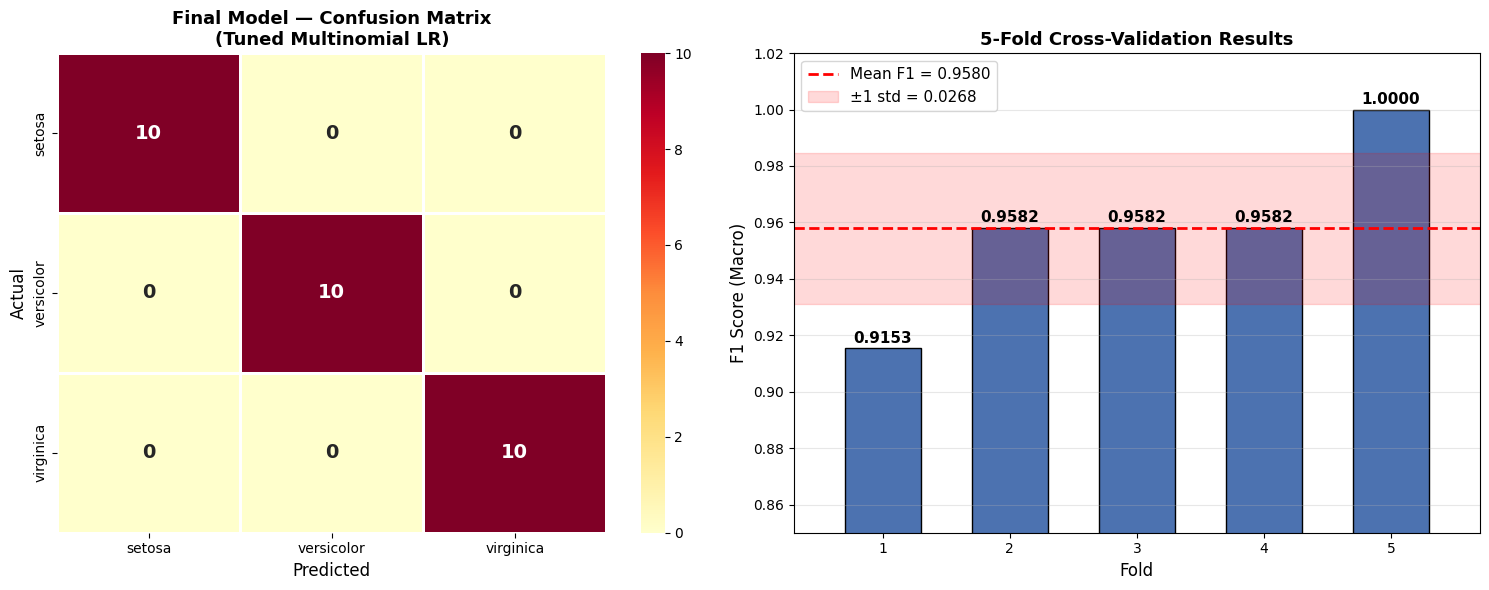

Q6 visualization saved.


In [9]:
# ── Q6 Pipeline Visualization ──

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Final confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            ax=axes[0], linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Final Model — Confusion Matrix\n(Tuned Multinomial LR)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Cross-validation scores
axes[1].bar(range(1, 6), cv_scores, color='#4C72B0', edgecolor='black', width=0.6)
axes[1].axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean F1 = {cv_scores.mean():.4f}')
axes[1].fill_between(range(0, 7),
                     cv_scores.mean()-cv_scores.std(),
                     cv_scores.mean()+cv_scores.std(),
                     alpha=0.15, color='red', label=f'±1 std = {cv_scores.std():.4f}')
for i, s in enumerate(cv_scores):
    axes[1].text(i+1, s+0.002, f'{s:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].set_ylabel('F1 Score (Macro)', fontsize=12)
axes[1].set_title('5-Fold Cross-Validation Results', fontsize=13, fontweight='bold')
axes[1].set_xlim(0.3, 5.7)
axes[1].set_ylim(0.85, 1.02)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q6_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q6 visualization saved.")

---
## Q7. Model Deployment and Why It Is Important

### What is Model Deployment?
**Model Deployment** is the process of making a trained machine learning model **available in a production environment** where it can receive real-world inputs and return predictions.

### Deployment Approaches

| Approach | Description | Example |
|---|---|---|
| **REST API** | Model wrapped in a web API | Flask, FastAPI, Django |
| **Batch Inference** | Predictions computed in bulk | Nightly report generation |
| **Streaming** | Real-time predictions on data streams | Kafka + Spark |
| **Edge Deployment** | Model runs on device (no cloud) | Mobile apps, IoT sensors |
| **Embedded** | Model inside another software | SDK, plugins |

### Why is Deployment Important?

1. **Business Value**: A model only creates value when it's generating predictions in production
2. **Real-World Testing**: Deployment exposes the model to real data distributions
3. **Scalability**: Serving predictions to thousands of users simultaneously
4. **Monitoring**: Track model performance over time, detect data drift
5. **Iteration**: Enables continuous improvement through retraining
6. **ROI**: Converts research investment into measurable business outcomes

### Deployment Stack (Typical)
```
Model (joblib/pickle) → API (FastAPI) → Docker Container
    → Kubernetes Cluster → Load Balancer → End Users
```

### Key Challenges
- **Reproducibility**: Same results in prod as dev (use Docker)
- **Latency**: Predictions must be fast enough for the use case
- **Scalability**: Handle traffic spikes
- **Model Drift**: Data distribution changes over time
- **Security**: Protect model and data from attacks

Simulating a REST API Deployment Pipeline

[1] Model Serialization
    joblib.dump(model, 'iris_classifier.pkl')  ✓

[2] Simulated API Request (POST /predict)
    Request body: {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
}

[3] API Response:
{
    "prediction": "setosa",
    "probabilities": {
        "setosa": 0.9975,
        "versicolor": 0.0025,
        "virginica": 0.0
    },
    "latency_ms": 7.9,
    "model_version": "1.0.0"
}

[4] Monitoring Metrics (Last 100 requests)
    Avg Latency   : 4.84 ms
    P95 Latency   : 7.22 ms
    Rolling Acc   : 0.9590
    Data Drift    : None detected


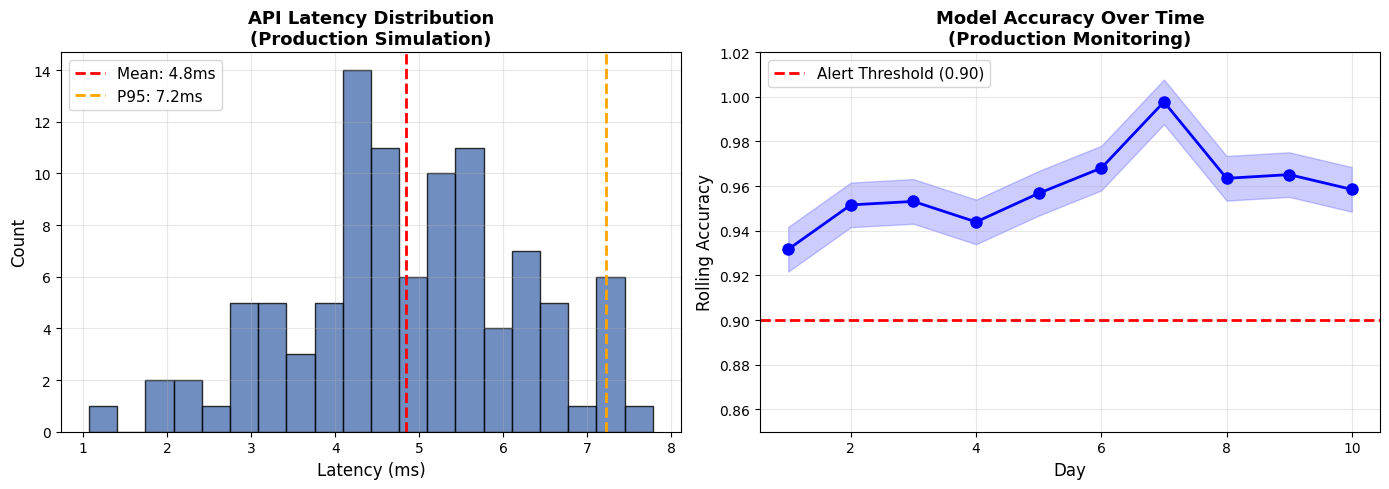

Q7 visualization saved.


In [10]:
# ── Q7 Demo: Simulated Deployment Pipeline ──

import time
import json

print("Simulating a REST API Deployment Pipeline")
print("=" * 55)

# Step 1: Save model (already done)
print("\n[1] Model Serialization")
print("    joblib.dump(model, 'iris_classifier.pkl')  ✓")

# Step 2: Simulate API request/response
print("\n[2] Simulated API Request (POST /predict)")
api_request = {
    "sepal_length": 5.1,
    "sepal_width":  3.5,
    "petal_length": 1.4,
    "petal_width":  0.2
}
print(f"    Request body: {json.dumps(api_request, indent=4)}")

# Step 3: Prediction
start = time.time()
loaded = joblib.load('iris_classifier.pkl')
input_arr = np.array([[api_request[k] for k in api_request]])
pred_class = iris.target_names[loaded.predict(input_arr)[0]]
pred_proba = loaded.predict_proba(input_arr)[0]
latency = (time.time() - start) * 1000

api_response = {
    "prediction": pred_class,
    "probabilities": {name: round(float(p), 4) for name, p in zip(iris.target_names, pred_proba)},
    "latency_ms": round(latency, 2),
    "model_version": "1.0.0"
}
print(f"\n[3] API Response:")
print(json.dumps(api_response, indent=4))

# Simulate monitoring metrics
print("\n[4] Monitoring Metrics (Last 100 requests)")
np.random.seed(42)
mock_latencies = np.random.normal(loc=5, scale=1.5, size=100)
mock_accuracies = np.random.normal(loc=0.96, scale=0.02, size=10)
print(f"    Avg Latency   : {mock_latencies.mean():.2f} ms")
print(f"    P95 Latency   : {np.percentile(mock_latencies, 95):.2f} ms")
print(f"    Rolling Acc   : {mock_accuracies.mean():.4f}")
print(f"    Data Drift    : None detected")

# Visualization: monitoring dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mock_latencies, bins=20, color='#4C72B0', edgecolor='black', alpha=0.8)
axes[0].axvline(mock_latencies.mean(), color='red',    linestyle='--', linewidth=2, label=f'Mean: {mock_latencies.mean():.1f}ms')
axes[0].axvline(np.percentile(mock_latencies, 95), color='orange', linestyle='--', linewidth=2,
                label=f'P95: {np.percentile(mock_latencies, 95):.1f}ms')
axes[0].set_title('API Latency Distribution\n(Production Simulation)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Latency (ms)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

days = range(1, 11)
axes[1].plot(days, mock_accuracies, 'bo-', linewidth=2, markersize=8)
axes[1].fill_between(days, mock_accuracies-0.01, mock_accuracies+0.01, alpha=0.2, color='blue')
axes[1].axhline(0.90, color='red', linestyle='--', linewidth=2, label='Alert Threshold (0.90)')
axes[1].set_title('Model Accuracy Over Time\n(Production Monitoring)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day', fontsize=12)
axes[1].set_ylabel('Rolling Accuracy', fontsize=12)
axes[1].set_ylim(0.85, 1.02)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q7_deployment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q7 visualization saved.")

---
## Q8. Multi-Cloud Platforms for Model Deployment

### What is Multi-Cloud?
**Multi-cloud** refers to using **two or more cloud providers** (e.g., AWS + Azure + GCP) simultaneously for deploying ML models and services, rather than relying on a single vendor.

### Major Cloud ML Platforms

| Cloud Provider | ML Platform | Key Services |
|---|---|---|
| **AWS** | Amazon SageMaker | Model training, endpoints, MLflow |
| **Google Cloud** | Vertex AI | AutoML, Prediction API, Pipelines |
| **Microsoft Azure** | Azure ML | Designer, Endpoints, MLOps |
| **IBM** | Watson ML | Model deployment, monitoring |

### How Multi-Cloud Deployment Works

```
                    ┌────────────────────────┐
                    │   ML Model (Docker)    │
                    └──────────┬─────────────┘
                               │
           ┌───────────────────┼───────────────────┐
           ▼                   ▼                   ▼
    ┌─────────────┐   ┌─────────────────┐   ┌───────────────┐
    │  AWS        │   │  Google Cloud   │   │  Azure        │
    │  SageMaker  │   │  Vertex AI      │   │  Azure ML     │
    │  Endpoint   │   │  Prediction API │   │  Endpoint     │
    └─────────────┘   └─────────────────┘   └───────────────┘
           │                   │                   │
           └───────────────────┴───────────────────┘
                               │
                    ┌──────────▼────────────┐
                    │   Load Balancer /     │
                    │   API Gateway         │
                    └──────────┬────────────┘
                               │
                         End Users
```

### MLOps Tools for Multi-Cloud
- **MLflow**: Experiment tracking across clouds
- **Kubernetes**: Container orchestration (cloud-agnostic)
- **Kubeflow**: ML pipelines on any Kubernetes
- **Terraform**: Infrastructure as Code across clouds
- **Docker**: Consistent packaging for any cloud
- **BentoML**: Model serving framework (cloud-agnostic)

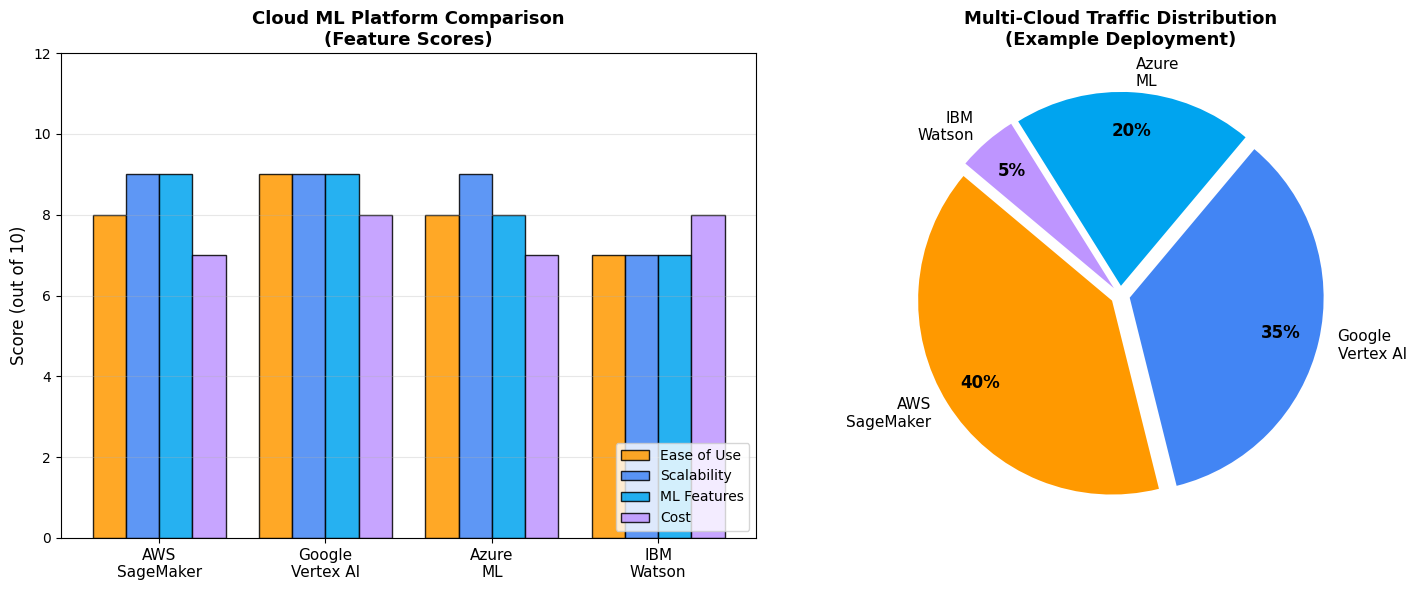

Q8 visualization saved.


In [11]:
# ── Q8 Demo: Multi-Cloud Architecture Visualization ──

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Cloud platform comparison
clouds = ['AWS\nSageMaker', 'Google\nVertex AI', 'Azure\nML', 'IBM\nWatson']
scores = {'Ease of Use': [8, 9, 8, 7],
           'Scalability': [9, 9, 9, 7],
           'ML Features': [9, 9, 8, 7],
           'Cost':        [7, 8, 7, 8]}

x = np.arange(len(clouds))
width = 0.2
colors_cloud = ['#FF9900', '#4285F4', '#00A4EF', '#BE95FF']

for i, (metric, values) in enumerate(scores.items()):
    offset = (i - 1.5) * width
    bars = axes[0].bar(x + offset, values, width, label=metric,
                       color=colors_cloud[i], edgecolor='black', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(clouds, fontsize=11)
axes[0].set_ylabel('Score (out of 10)', fontsize=12)
axes[0].set_title('Cloud ML Platform Comparison\n(Feature Scores)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='lower right')
axes[0].set_ylim(0, 12)
axes[0].grid(axis='y', alpha=0.3)

# Multi-cloud traffic distribution
traffic_shares = [40, 35, 20, 5]
colors_pie = ['#FF9900', '#4285F4', '#00A4EF', '#BE95FF']
explode = (0.05, 0.05, 0.05, 0.05)
wedges, texts, autotexts = axes[1].pie(
    traffic_shares, labels=clouds, colors=colors_pie,
    autopct='%1.0f%%', startangle=140, explode=explode,
    textprops={'fontsize': 11}, pctdistance=0.8
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[1].set_title('Multi-Cloud Traffic Distribution\n(Example Deployment)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('q8_multicloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q8 visualization saved.")

---
## Q9. Benefits and Challenges of Multi-Cloud ML Deployment

### ✅ Benefits

| Benefit | Description |
|---|---|
| **Vendor Independence** | No lock-in to a single provider; switch anytime |
| **Best-of-Breed** | Use the best service from each cloud (e.g., GCP for BigQuery, AWS for SageMaker) |
| **High Availability** | If one cloud goes down, traffic routes to another |
| **Cost Optimization** | Workloads run on cheapest provider at any given time |
| **Global Latency** | Deploy models closer to users worldwide |
| **Regulatory Compliance** | Different regions may require data in specific jurisdictions |
| **Disaster Recovery** | Geographic and provider redundancy |
| **Negotiation Power** | Competition between providers keeps costs down |

### ⚠️ Challenges

| Challenge | Description |
|---|---|
| **Complexity** | Managing multiple cloud environments significantly increases operational overhead |
| **Data Transfer Costs** | Moving data between clouds (egress fees) can be expensive |
| **Consistency** | Ensuring the same model version runs on all clouds |
| **Security** | Each cloud has different security models; unified IAM is difficult |
| **Monitoring** | Aggregating logs and metrics from multiple clouds |
| **Skill Requirements** | Teams need expertise in multiple cloud platforms |
| **Latency** | Inter-cloud communication adds latency |
| **Data Governance** | Ensuring compliance across jurisdictions |

### Best Practices
- Use **Kubernetes** for portable, consistent deployment
- Use **Terraform** for infrastructure as code across clouds
- Use **MLflow** or **Weights & Biases** for unified experiment tracking
- Use a **service mesh** (e.g., Istio) for cross-cloud service discovery
- Implement **centralized logging** (e.g., Datadog, Grafana)
- Design for **statelessness** — each inference request is independent

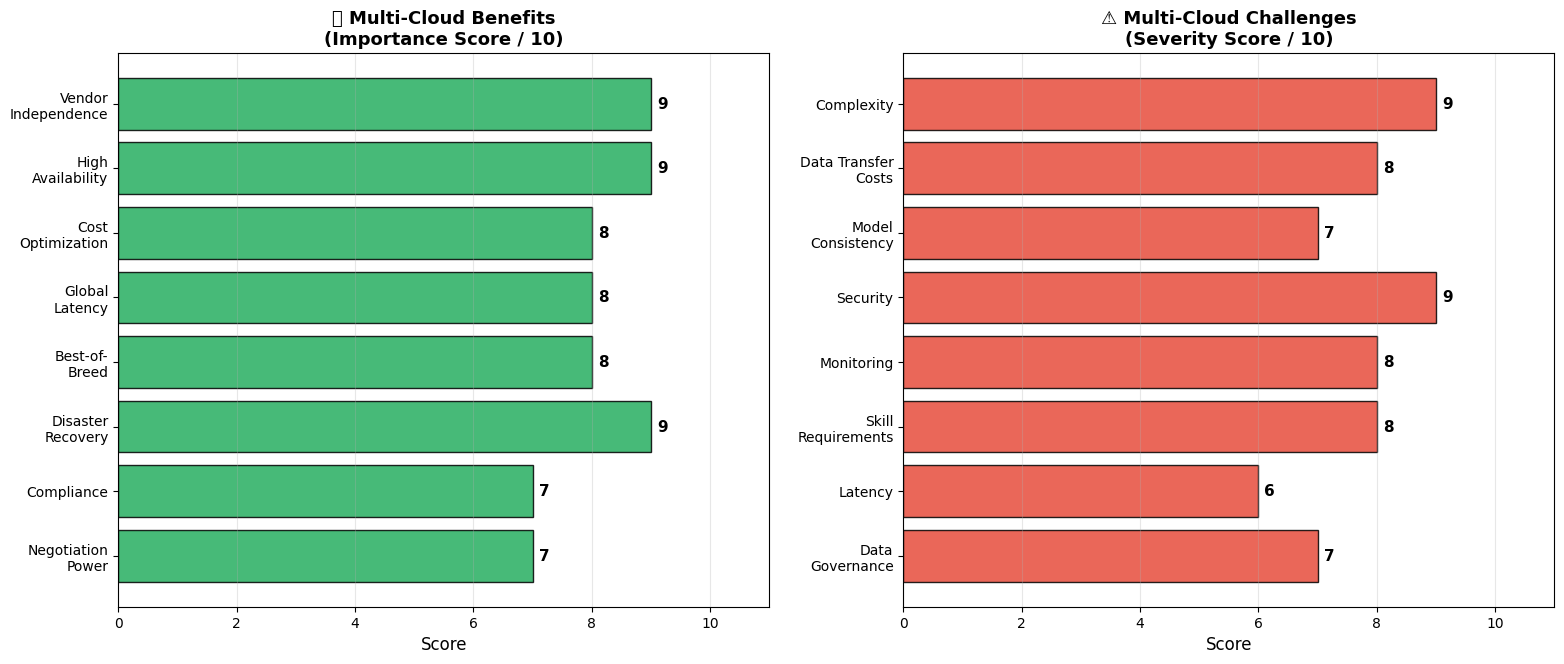

Q9 visualization saved.

      ALL QUESTIONS ANSWERED SUCCESSFULLY!
  Outputs generated:
  ✓ q1_precision_recall.png
  ✓ q2_f1_score.png
  ✓ q3_roc_auc.png
  ✓ q4_metric_selection.png
  ✓ q5_multiclass_lr.png
  ✓ q6_pipeline.png
  ✓ q7_deployment.png
  ✓ q8_multicloud.png
  ✓ q9_multicloud_challenges.png
  ✓ iris_classifier.pkl


In [12]:
# ── Q9 Demo: Multi-Cloud Benefits & Challenges Summary Chart ──

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Benefits radar-style bar chart
benefits = ['Vendor\nIndependence', 'High\nAvailability', 'Cost\nOptimization',
            'Global\nLatency', 'Best-of-\nBreed', 'Disaster\nRecovery',
            'Compliance', 'Negotiation\nPower']
b_scores = [9, 9, 8, 8, 8, 9, 7, 7]
colors_b = ['#27AE60'] * len(benefits)
bars_b = axes[0].barh(benefits, b_scores, color=colors_b, edgecolor='black', alpha=0.85)
for bar, score in zip(bars_b, b_scores):
    axes[0].text(score + 0.1, bar.get_y() + bar.get_height()/2,
                 str(score), va='center', fontweight='bold', fontsize=11)
axes[0].set_xlim(0, 11)
axes[0].set_title('✅ Multi-Cloud Benefits\n(Importance Score / 10)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Challenges bar chart
challenges = ['Complexity', 'Data Transfer\nCosts', 'Model\nConsistency',
              'Security', 'Monitoring', 'Skill\nRequirements',
              'Latency', 'Data\nGovernance']
c_scores = [9, 8, 7, 9, 8, 8, 6, 7]
colors_c = ['#E74C3C'] * len(challenges)
bars_c = axes[1].barh(challenges, c_scores, color=colors_c, edgecolor='black', alpha=0.85)
for bar, score in zip(bars_c, c_scores):
    axes[1].text(score + 0.1, bar.get_y() + bar.get_height()/2,
                 str(score), va='center', fontweight='bold', fontsize=11)
axes[1].set_xlim(0, 11)
axes[1].set_title('⚠️ Multi-Cloud Challenges\n(Severity Score / 10)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout(pad=2.0)
plt.savefig('q9_multicloud_challenges.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q9 visualization saved.")

print("\n" + "=" * 60)
print("      ALL QUESTIONS ANSWERED SUCCESSFULLY!")
print("=" * 60)
print("  Outputs generated:")
outputs = [
    "q1_precision_recall.png",
    "q2_f1_score.png",
    "q3_roc_auc.png",
    "q4_metric_selection.png",
    "q5_multiclass_lr.png",
    "q6_pipeline.png",
    "q7_deployment.png",
    "q8_multicloud.png",
    "q9_multicloud_challenges.png",
    "iris_classifier.pkl"
]
for o in outputs:
    print(f"  ✓ {o}")
print("=" * 60)